In [11]:
import os
import sys
import re
import warnings
import pickle
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
from dataclasses import dataclass, field
from tqdm.auto import tqdm

import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_PATH = project_root / 'data' / 'raw' / 'IEEE_PHM' / 'dataset'
PROCESSED_DIR = project_root / 'data' / 'processed' / 'ieee_phm'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data path: {DATA_PATH}")

Project root: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel
Data path: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/raw/IEEE_PHM/dataset


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# 2. HYPERPARAMETERS
# Windowing Raw Signal (To get features)
RAW_WINDOW_SIZE = 256
RAW_STRIDE = 128

# GRU Sequence (History) - CHANGED: Use smaller seq_len
# 256 might over-smooth degradation, try 128 or 64
GRU_SEQ_LEN = 128  # CHANGED: Reduced from 256 to better capture degradation
N_FEATURES = 8     # The 8 calculated features

# Training Params
BATCH_SIZE = 16
EPOCHS = 50  # Increased slightly for better convergence
LEARNING_RATE = 0.001

# ✅ CORRECTED: Use bearings from same condition (Condition 1)
# Only Condition 1 data to maintain domain consistency
TRAIN_BEARINGS = ['Bearing1_1', 'Bearing1_2']     # Training
VAL_BEARING = 'Bearing1_7'                         # Validation (separate bearing)
TEST_BEARINGS = ['Bearing1_3', 'Bearing1_5', 'Bearing1_6']  # Test

print("=" * 70)
print("BEARING-WISE DATA SPLIT (Domain Consistent):")
print(f"  Training Bearings: {TRAIN_BEARINGS}")
print(f"  Validation Bearing: {VAL_BEARING}")
print(f"  Test Bearings: {TEST_BEARINGS}")
print("=" * 70)

# 3. FEATURE CALCULATION (On a Window, not whole file)
def calculate_features_on_window(window_data):
    """
    Calculates 8 features for a single window (256, 2)
    """
    h_sig = window_data[:, 0]
    v_sig = window_data[:, 1]
    abs_h = np.abs(h_sig)

    # Features
    f1 = np.mean(h_sig)                  # H_Mean
    f2 = np.mean(v_sig)                  # V_Mean
    f3 = np.std(h_sig)                   # P2 (Std)
    f4 = np.sqrt(np.mean(h_sig**2))      # P4 (RMS)
    f5 = np.max(h_sig)                   # P5 (Max)
    f6 = np.mean(abs_h)                  # P9 (MAV)
    f7 = (np.mean(np.sqrt(abs_h)))**2    # P10 (Root Amp)

    # P28 (Spectral Mean)
    fft_vals = np.abs(np.fft.fft(h_sig))[:len(h_sig)//2]
    f8 = np.mean(fft_vals)

    return np.array([f1, f2, f3, f4, f5, f6, f7, f8])

def process_file_into_windows(filepath, raw_window=256, raw_stride=128):
    """
    Slices one file (2560 points) into multiple windows and extracts features.
    Returns: Matrix of shape (Num_Windows, 8)
    """
    try:
        # Load Raw Data (2560, 2)
        df = pd.read_csv(filepath, header=None, usecols=[4, 5])
        data = df.values

        features_in_file = []

        # Slide window over the raw 2560 points
        for i in range(0, len(data) - raw_window + 1, raw_stride):
            window = data[i : i + raw_window]
            feats = calculate_features_on_window(window)
            features_in_file.append(feats)

        return np.array(features_in_file)
    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        return None

def load_bearing_data_corrected(bearing_name):
    """
    ✅ CORRECTED APPROACH:
    1. Load all files from a bearing
    2. Extract features for all windows
    3. Assign RUL: Linear degradation from 1.0 → 0.0 across ALL windows in bearing
    4. NO reset per file - continuous degradation
    5. Do NOT let sequences cross bearing boundaries

    Returns: (Total_Windows_In_Bearing, 8) and corresponding linear RULs
    """
    search_path = os.path.join(DATA_PATH, '**', bearing_name)
    found = glob.glob(search_path, recursive=True)

    if not found:
        raise FileNotFoundError(f"Bearing {bearing_name} not found!")

    folder = found[0]
    all_files = sorted(glob.glob(os.path.join(folder, 'acc_*.csv')))

    print(f"\n📂 Loading {bearing_name}:")
    print(f"   Found {len(all_files)} files")

    all_features = []

    # Extract features from all files
    for f in tqdm(all_files, desc=f"Processing {bearing_name}", leave=False):
        windows_feats = process_file_into_windows(f, RAW_WINDOW_SIZE, RAW_STRIDE)
        if windows_feats is not None:
            all_features.append(windows_feats)

    # Stack all windows from this bearing
    X_bearing = np.vstack(all_features)

    # ✅ KEY FIX: Assign RUL per window (not per file)
    # Linear degradation from 1.0 to 0.0 across all windows in bearing
    N_total_windows = len(X_bearing)
    y_bearing = np.linspace(1.0, 0.0, N_total_windows)

    print(f"   ✅ Total windows in bearing: {N_total_windows}")
    print(f"   ✅ RUL range: {y_bearing[0]:.4f} → {y_bearing[-1]:.4f}")
    print(f"   Features shape: {X_bearing.shape}")

    return X_bearing, y_bearing

# 4. CREATE GRU SEQUENCES (Within each bearing - NO crossing)
def create_gru_sequences_for_bearing(X_data, y_data, seq_len=128):
    """
    ✅ CORRECTED: Create GRU sequences within a single bearing
    This ensures sequences don't cross bearing boundaries (no domain shift within sequences)

    Args:
        X_data: (N_windows, 8) - features for one bearing
        y_data: (N_windows,) - RUL values for one bearing
        seq_len: 128 - sequence length

    Returns:
        Xs: (N_sequences, seq_len, 8)
        ys: (N_sequences,) - RUL at end of sequence
    """
    Xs, ys = [], []

    # Slide window with stride=1 for maximum utilization
    for i in range(len(X_data) - seq_len):
        Xs.append(X_data[i : i + seq_len])
        ys.append(y_data[i + seq_len - 1])  # Predict RUL at end of sequence

    return np.array(Xs), np.array(ys)

# 5. PREPARE DATASETS (Bearing-wise)
def prepare_datasets_corrected():
    """
    ✅ CORRECTED PIPELINE:
    1. Load each bearing separately
    2. Assign RUL per window (linear degradation)
    3. Create sequences within each bearing (no boundary crossing)
    4. Normalize using scaler fit on training data only
    5. Split into train/val/test by bearing
    """

    print("\n" + "=" * 70)
    print("STEP 1: Load and process all bearings")
    print("=" * 70)

    # Load each bearing separately
    bearings_data = {}

    # Training bearings
    for bearing in TRAIN_BEARINGS:
        X, y = load_bearing_data_corrected(bearing)
        bearings_data[bearing] = {'X': X, 'y': y}

    # Validation bearing
    X, y = load_bearing_data_corrected(VAL_BEARING)
    bearings_data[VAL_BEARING] = {'X': X, 'y': y}

    # Test bearings
    for bearing in TEST_BEARINGS:
        X, y = load_bearing_data_corrected(bearing)
        bearings_data[bearing] = {'X': X, 'y': y}

    print("\n" + "=" * 70)
    print("STEP 2: Normalize features (fit on training data only)")
    print("=" * 70)

    # ✅ Fit scaler ONLY on training data
    X_train_raw = np.vstack([bearings_data[b]['X'] for b in TRAIN_BEARINGS])
    scaler = MinMaxScaler()
    scaler.fit(X_train_raw)

    print(f"✅ Scaler fitted on {X_train_raw.shape[0]} training samples")

    # Normalize all bearings with the same scaler
    for bearing in bearings_data:
        bearings_data[bearing]['X'] = scaler.transform(bearings_data[bearing]['X'])

    print("\n" + "=" * 70)
    print("STEP 3: Create GRU sequences (within each bearing)")
    print("=" * 70)

    # Create sequences for each bearing separately
    sequences_train = []
    ruls_train = []

    for bearing in TRAIN_BEARINGS:
        X_seq, y_seq = create_gru_sequences_for_bearing(
            bearings_data[bearing]['X'],
            bearings_data[bearing]['y'],
            seq_len=GRU_SEQ_LEN
        )
        sequences_train.append(X_seq)
        ruls_train.append(y_seq)
        print(f"✅ {bearing}: {X_seq.shape[0]} sequences created")

    # Concatenate sequences from training bearings
    X_train = np.vstack(sequences_train).astype('float32')
    y_train = np.concatenate(ruls_train).astype('float32')

    # Validation sequences
    X_val_seq, y_val_seq = create_gru_sequences_for_bearing(
        bearings_data[VAL_BEARING]['X'],
        bearings_data[VAL_BEARING]['y'],
        seq_len=GRU_SEQ_LEN
    )
    X_val = X_val_seq.astype('float32')
    y_val = y_val_seq.astype('float32')
    print(f"✅ {VAL_BEARING}: {X_val.shape[0]} sequences created")

    # Test sequences (concatenate from all test bearings)
    sequences_test = []
    ruls_test = []

    for bearing in TEST_BEARINGS:
        X_seq, y_seq = create_gru_sequences_for_bearing(
            bearings_data[bearing]['X'],
            bearings_data[bearing]['y'],
            seq_len=GRU_SEQ_LEN
        )
        sequences_test.append(X_seq)
        ruls_test.append(y_seq)
        print(f"✅ {bearing}: {X_seq.shape[0]} sequences created")

    X_test = np.vstack(sequences_test).astype('float32')
    y_test = np.concatenate(ruls_test).astype('float32')

    print("\n" + "=" * 70)
    print("✅ FINAL DATASETS READY")
    print("=" * 70)
    print(f"Train: {X_train.shape} -> {y_train.shape}")
    print(f"Val:   {X_val.shape} -> {y_val.shape}")
    print(f"Test:  {X_test.shape} -> {y_test.shape}")
    print("=" * 70)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler


BEARING-WISE DATA SPLIT (Domain Consistent):
  Training Bearings: ['Bearing1_1', 'Bearing1_2']
  Validation Bearing: Bearing1_7
  Test Bearings: ['Bearing1_3', 'Bearing1_5', 'Bearing1_6']


In [13]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = prepare_datasets_corrected()


STEP 1: Load and process all bearings

📂 Loading Bearing1_1:
   Found 2803 files


   ✅ Total windows in bearing: 53257
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (53257, 8)

📂 Loading Bearing1_2:
   Found 871 files


   ✅ Total windows in bearing: 16549
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (16549, 8)

📂 Loading Bearing1_7:
   Found 2259 files


   ✅ Total windows in bearing: 42921
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (42921, 8)

📂 Loading Bearing1_3:
   Found 2375 files


   ✅ Total windows in bearing: 45125
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (45125, 8)

📂 Loading Bearing1_5:
   Found 2463 files


   ✅ Total windows in bearing: 46797
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (46797, 8)

📂 Loading Bearing1_6:
   Found 2448 files


   ✅ Total windows in bearing: 46512
   ✅ RUL range: 1.0000 → 0.0000
   Features shape: (46512, 8)

STEP 2: Normalize features (fit on training data only)
✅ Scaler fitted on 69806 training samples

STEP 3: Create GRU sequences (within each bearing)
✅ Bearing1_1: 53129 sequences created
✅ Bearing1_2: 16421 sequences created
✅ Bearing1_7: 42793 sequences created
✅ Bearing1_3: 44997 sequences created
✅ Bearing1_5: 46669 sequences created
✅ Bearing1_6: 46384 sequences created

✅ FINAL DATASETS READY
Train: (69550, 128, 8) -> (69550,)
Val:   (42793, 128, 8) -> (42793,)
Test:  (138050, 128, 8) -> (138050,)


In [14]:
# ===============================================================
# SECTION 2: Dataset Statistics & Summary
# ===============================================================

print("=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)

for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    print(f"\n{'─'*40}")
    print(f"  {name} Set:")
    print(f"    X shape: {X.shape}")
    print(f"    y shape: {y.shape}")
    print(f"    y range: [{y.min():.4f}, {y.max():.4f}]")
    print(f"    y mean:  {y.mean():.4f} ± {y.std():.4f}")
    print(f"    X min/max per feature:")
    for i in range(X.shape[-1]):
        feat_vals = X[:, :, i].flatten()
        print(f"      Feature {i}: [{feat_vals.min():.4f}, {feat_vals.max():.4f}] "
              f"mean={feat_vals.mean():.4f}")

FEATURE_NAMES = ['H_Mean', 'V_Mean', 'Std', 'RMS', 'Max', 'MAV', 'Root_Amp', 'Spectral_Mean']
print(f"\nFeature names: {FEATURE_NAMES}")

📊 DATASET STATISTICS

────────────────────────────────────────
  Train Set:
    X shape: (69550, 128, 8)
    y shape: (69550,)
    y range: [0.0000, 0.9976]
    y mean:  0.4982 ± 0.2876
    X min/max per feature:
      Feature 0: [0.0000, 1.0000] mean=0.5005
      Feature 1: [0.0000, 1.0000] mean=0.9121
      Feature 2: [0.0000, 1.0000] mean=0.0302
      Feature 3: [0.0000, 1.0000] mean=0.0303
      Feature 4: [0.0000, 1.0000] mean=0.0298
      Feature 5: [0.0000, 1.0000] mean=0.0343
      Feature 6: [0.0000, 1.0000] mean=0.0390
      Feature 7: [0.0000, 1.0000] mean=0.0293

────────────────────────────────────────
  Val Set:
    X shape: (42793, 128, 8)
    y shape: (42793,)
    y range: [0.0000, 0.9970]
    y mean:  0.4985 ± 0.2878
    X min/max per feature:
      Feature 0: [0.2955, 0.5847] mean=0.5008
      Feature 1: [0.8466, 0.9730] mean=0.9120
      Feature 2: [0.0007, 0.3133] mean=0.0142
      Feature 3: [0.0009, 0.3132] mean=0.0143
      Feature 4: [0.0004, 0.5337] mean=0.0168

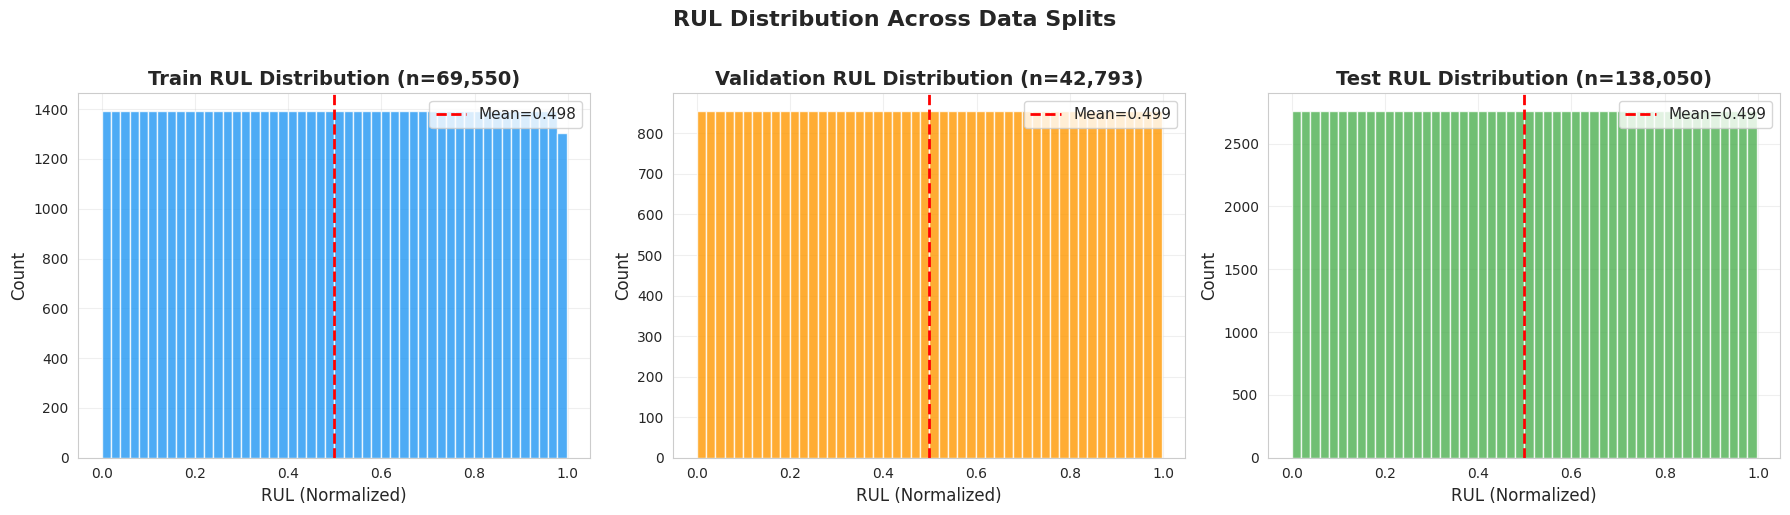

✅ Saved: rul_distribution.png


In [15]:
# ===============================================================
# PLOT 1: RUL Distribution across splits
# ===============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y, color) in zip(axes, [
    ("Train", y_train, "#2196F3"),
    ("Validation", y_val, "#FF9800"),
    ("Test", y_test, "#4CAF50")
]):
    ax.hist(y, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={y.mean():.3f}')
    ax.set_title(f'{name} RUL Distribution (n={len(y):,})', fontsize=14, fontweight='bold')
    ax.set_xlabel('RUL (Normalized)', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('RUL Distribution Across Data Splits', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'rul_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rul_distribution.png")

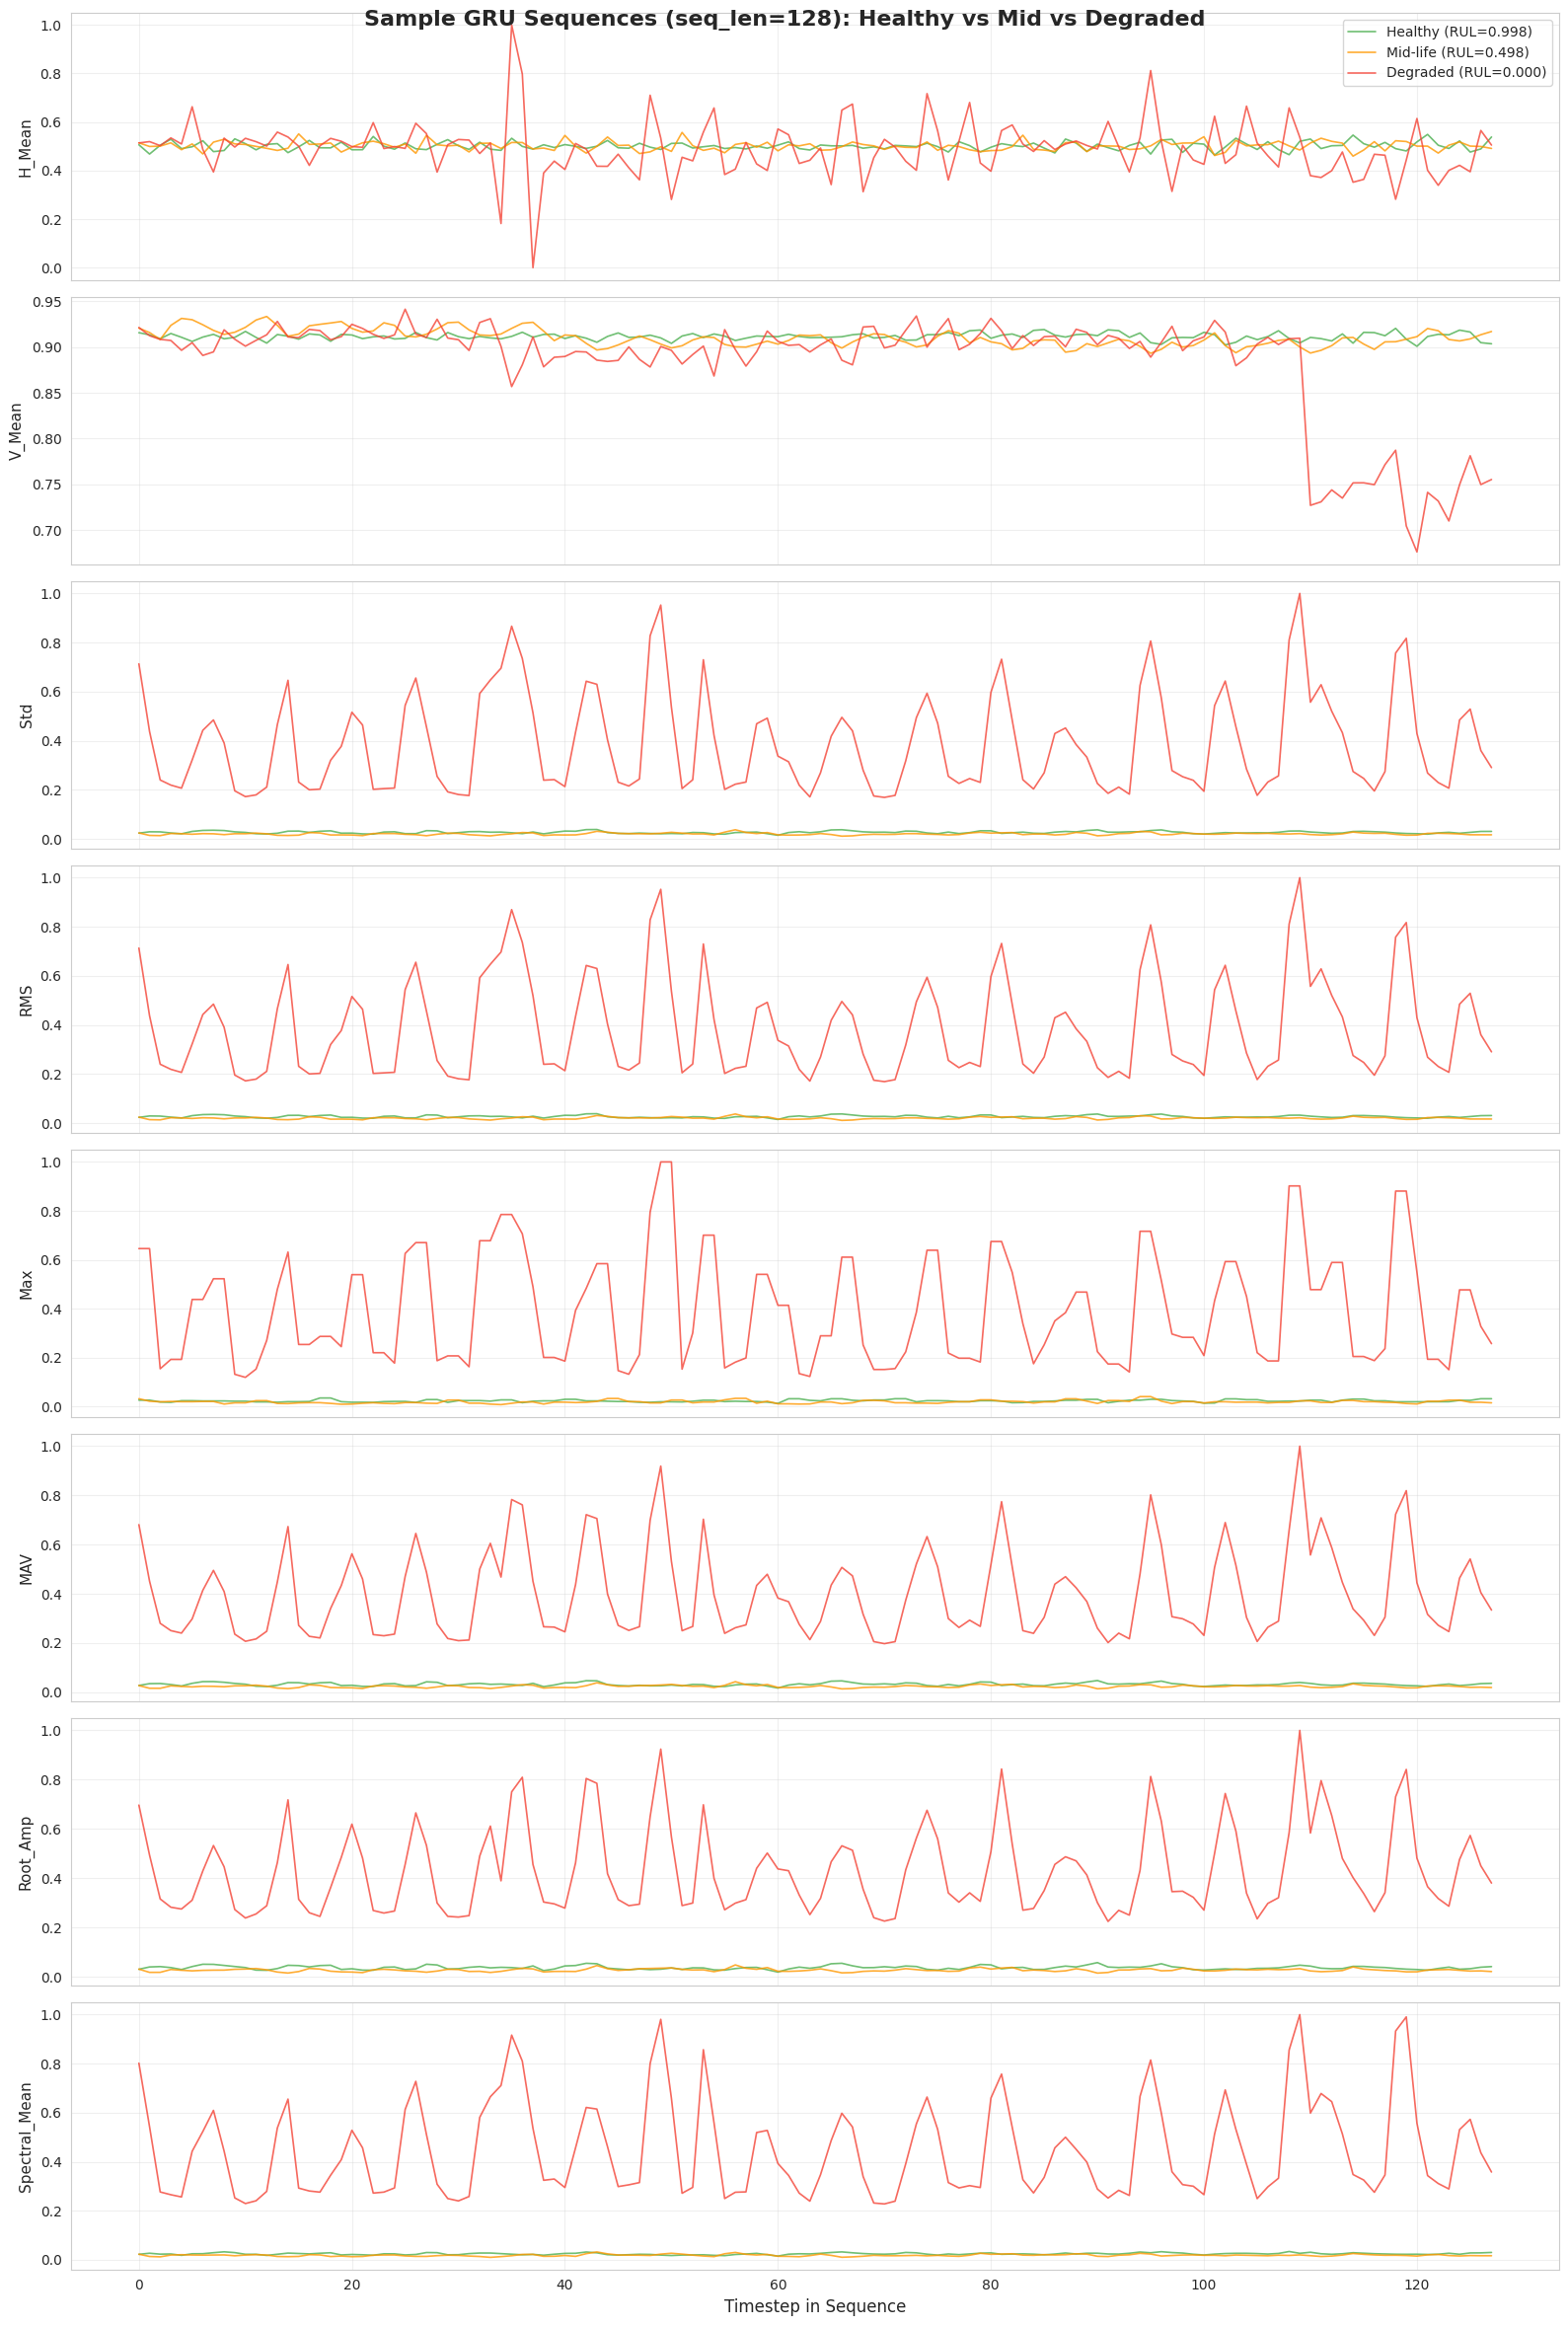

✅ Saved: sample_sequences.png


In [16]:
# ===============================================================
# PLOT 4: Sample GRU Sequences (Healthy vs Mid vs Degraded)
# ===============================================================

# Pick 3 representative samples
sorted_indices = np.argsort(y_train)
idx_healthy = sorted_indices[-1]          # Highest RUL
idx_mid = sorted_indices[len(sorted_indices) // 2]  # Mid RUL
idx_degraded = sorted_indices[0]          # Lowest RUL

samples = [
    ("Healthy (RUL={:.3f})".format(y_train[idx_healthy]), X_train[idx_healthy], '#4CAF50'),
    ("Mid-life (RUL={:.3f})".format(y_train[idx_mid]), X_train[idx_mid], '#FF9800'),
    ("Degraded (RUL={:.3f})".format(y_train[idx_degraded]), X_train[idx_degraded], '#F44336'),
]

fig, axes = plt.subplots(len(FEATURE_NAMES), 1, figsize=(16, 24), sharex=True)

for feat_idx, (ax, fname) in enumerate(zip(axes, FEATURE_NAMES)):
    for label, seq, color in samples:
        ax.plot(seq[:, feat_idx], label=label, color=color, alpha=0.8, linewidth=1.2)
    ax.set_ylabel(fname, fontsize=11)
    ax.grid(True, alpha=0.3)
    if feat_idx == 0:
        ax.legend(loc='upper right', fontsize=10)

axes[-1].set_xlabel('Timestep in Sequence', fontsize=12)
plt.suptitle(f'Sample GRU Sequences (seq_len={GRU_SEQ_LEN}): Healthy vs Mid vs Degraded',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sample_sequences.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sample_sequences.png")

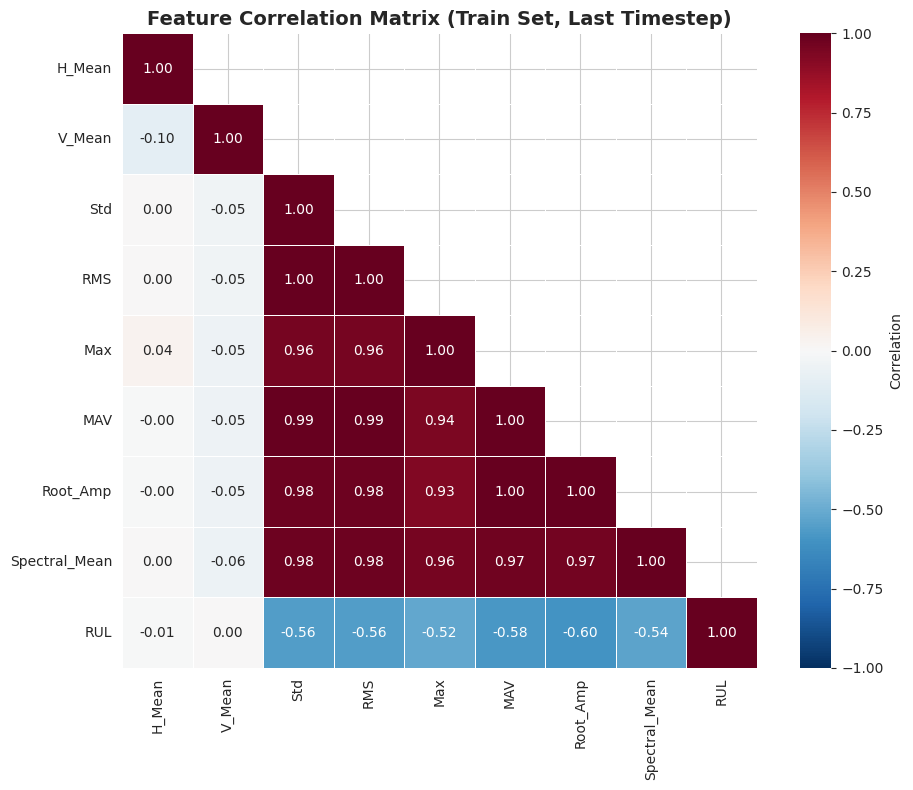

✅ Saved: correlation_heatmap.png


In [17]:
# ===============================================================
# PLOT 5: Feature Correlation Heatmap
# ===============================================================

# Use last timestep features from training set
last_step_features = X_train[:, -1, :]  # (N, 8)
df_feats = pd.DataFrame(last_step_features, columns=FEATURE_NAMES)
df_feats['RUL'] = y_train

corr_matrix = df_feats.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Feature Correlation Matrix (Train Set, Last Timestep)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: correlation_heatmap.png")

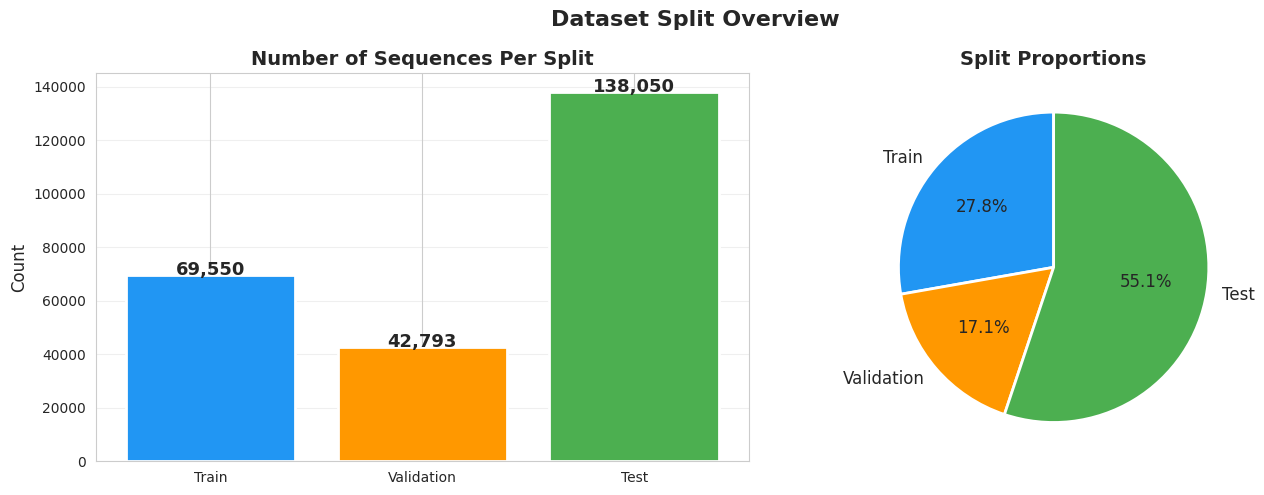

✅ Saved: dataset_split_overview.png


In [18]:
# ===============================================================
# PLOT 6: Dataset Size Comparison
# ===============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: sample counts
splits = ['Train', 'Validation', 'Test']
counts = [len(y_train), len(y_val), len(y_test)]
colors = ['#2196F3', '#FF9800', '#4CAF50']

bars = axes[0].bar(splits, counts, color=colors, edgecolor='white', linewidth=2)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Number of Sequences Per Split', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart: proportions
axes[1].pie(counts, labels=splits, autopct='%1.1f%%', colors=colors,
            startangle=90, textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Split Proportions', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Split Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'dataset_split_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dataset_split_overview.png")

In [19]:
# ===============================================================
# SECTION 3: PyTorch Dataset & DataLoaders
# ===============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

class RULDataset(Dataset):
    """PyTorch Dataset for RUL prediction sequences."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        """
        Args:
            X: numpy array of shape (N, seq_len, n_features)
            y: numpy array of shape (N,)
        """
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = RULDataset(X_train, y_train)
val_dataset = RULDataset(X_val, y_val)
test_dataset = RULDataset(X_test, y_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print("\n" + "=" * 70)
print("✅ PyTorch DataLoaders Created")
print("=" * 70)
print(f"  Train: {len(train_dataset):,} samples → {len(train_loader)} batches (batch_size={BATCH_SIZE})")
print(f"  Val:   {len(val_dataset):,} samples → {len(val_loader)} batches")
print(f"  Test:  {len(test_dataset):,} samples → {len(test_loader)} batches")

# Verify shapes
X_batch, y_batch = next(iter(train_loader))
print(f"\n📐 Batch shapes:")
print(f"  X_batch: {X_batch.shape}  (batch, seq_len, n_features)")
print(f"  y_batch: {y_batch.shape}  (batch, 1)")
print(f"  X dtype: {X_batch.dtype}, y dtype: {y_batch.dtype}")

🖥️ Using device: cuda

✅ PyTorch DataLoaders Created
  Train: 69,550 samples → 4347 batches (batch_size=16)
  Val:   42,793 samples → 2675 batches
  Test:  138,050 samples → 8629 batches


/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 Quadro P1000 which is of cuda capability 6.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  warnings.warn(
/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/home/rdb/Documents/nirban_documents/python_programs/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:326: UserWarning: 
Quadro P1000 with CUDA capability sm_61 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the


📐 Batch shapes:
  X_batch: torch.Size([16, 128, 8])  (batch, seq_len, n_features)
  y_batch: torch.Size([16, 1])  (batch, 1)
  X dtype: torch.float32, y dtype: torch.float32


In [20]:
# ===============================================================
# SECTION 4: Save Processed Data
# ===============================================================

print("=" * 70)
print("💾 SAVING PROCESSED DATA")
print("=" * 70)

# 1. Save numpy arrays (for general use)
np.savez_compressed(
    PROCESSED_DIR / 'ieee_phm_sequences.npz',
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_test=X_test, y_test=y_test,
)
print(f"✅ Sequences saved: {PROCESSED_DIR / 'ieee_phm_sequences.npz'}")

# 2. Save scaler
with open(PROCESSED_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved: {PROCESSED_DIR / 'scaler.pkl'}")

# 3. Save PyTorch datasets (for direct loading in training notebook)
torch.save({
    'train_dataset': train_dataset,
    'val_dataset': val_dataset,
    'test_dataset': test_dataset,
}, PROCESSED_DIR / 'torch_datasets.pt')
print(f"✅ Torch datasets saved: {PROCESSED_DIR / 'torch_datasets.pt'}")

# 4. Save hyperparameters as JSON
hyperparams = {
    'RAW_WINDOW_SIZE': RAW_WINDOW_SIZE,
    'RAW_STRIDE': RAW_STRIDE,
    'GRU_SEQ_LEN': GRU_SEQ_LEN,
    'N_FEATURES': N_FEATURES,
    'FEATURE_NAMES': FEATURE_NAMES,
    'BATCH_SIZE': BATCH_SIZE,
    'EPOCHS': EPOCHS,
    'LEARNING_RATE': LEARNING_RATE,
    'TRAIN_BEARINGS': TRAIN_BEARINGS,
    'VAL_BEARING': VAL_BEARING,
    'TEST_BEARINGS': TEST_BEARINGS,
    'train_samples': len(y_train),
    'val_samples': len(y_val),
    'test_samples': len(y_test),
}

with open(PROCESSED_DIR / 'hyperparams.json', 'w') as f:
    json.dump(hyperparams, f, indent=2)
print(f"✅ Hyperparams saved: {PROCESSED_DIR / 'hyperparams.json'}")

# 5. Summary of saved files
print("\n" + "=" * 70)
print("📁 FILES SAVED IN:", PROCESSED_DIR)
print("=" * 70)
for fpath in sorted(PROCESSED_DIR.iterdir()):
    size_mb = fpath.stat().st_size / (1024 * 1024)
    print(f"  {fpath.name:40s} {size_mb:8.2f} MB")

print("\n✅ All preprocessing complete! Ready for training notebook.")


💾 SAVING PROCESSED DATA
✅ Sequences saved: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm/ieee_phm_sequences.npz
✅ Scaler saved: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm/scaler.pkl
✅ Torch datasets saved: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm/torch_datasets.pt
✅ Hyperparams saved: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm/hyperparams.json

📁 FILES SAVED IN: /home/rdb/Documents/nirban_documents/python_programs/counterfactual_basis_kernel/data/processed/ieee_phm
  X_train.npy                                  0.18 MB
  cleaned_bearing_data.pkl                    13.99 MB
  correlation_heatmap.png                      0.11 MB
  dataset_split_overview.png                   0.08 MB
  hyperparams.json                             0.00 MB
  ieee_p